
# SE-2024_assignment1_Name_Surname

## Machine Learning Workflow Report: Cybersecurity Threat Detection

**Major:** Cybersecurity  
**Dataset:** Cybersecurity Threat Detection Logs (Kaggle)  
**Link:** https://www.kaggle.com/datasets/aryan208/cybersecurity-threat-detection-logs



## 1. Dataset Selection

I selected this dataset because it is directly related to cybersecurity operations and incident response.
The data contains event logs that can be used to train a model to classify potential threats.

A practical machine learning model on such data can help security teams prioritize alerts and reduce manual triage effort.



## 2. Business Understanding

### Real-world task
The task is to classify whether a network/system log event is associated with a cybersecurity threat category.

### Decision support
The model supports SOC (Security Operations Center) analysts by providing a fast initial prediction for incoming logs.

### Stakeholders
- SOC analysts
- Incident response team
- Security managers

### Expected impact
- Faster triage time
- Better prioritization of suspicious events
- Reduced operational risk from delayed detection

### Success criteria (business acceptance targets)
For a baseline academic model:
- **F1-score >= 0.75** on test set
- **Recall >= 0.80** for threat class (if binary) or strong macro recall (if multiclass)
- Stable confusion matrix without severe collapse of any class


## 3. Setup & Imports

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', 100)


## 4. Load Data

In [2]:

# Update this path if needed
DATA_PATH = 'cybersecurity_threat_detection_logs.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()


Shape: (6000000, 10)


,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path
0,2024-05-01T00:00:00,192.168.1.125,192.168.1.124,TCP,blocked,benign,firewall,10889,Nmap Scripting Engine,/
1,2024-07-18T00:00:00,192.168.1.201,192.168.1.201,ICMP,blocked,benign,application,36522,Nmap Scripting Engine,/
2,2024-04-07T00:00:00,192.168.1.248,192.168.1.15,HTTP,allowed,benign,application,20652,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/login
3,2024-10-26T00:00:00,192.168.1.236,192.168.1.219,HTTP,allowed,benign,application,5350,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,/login
4,2024-10-31T00:00:00,192.168.1.221,192.168.1.61,ICMP,allowed,benign,application,40691,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/



## 5. Exploratory Data Analysis (EDA)

In this section we describe the dataset, inspect data types, summary statistics, class balance, and basic feature relationships.


In [3]:

print('Column types:')
print(df.dtypes)

print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

print('\nDuplicate rows:', df.duplicated().sum())

display(df.describe(include='all').T.head(20))

Column types:
timestamp              str
source_ip              str
dest_ip                str
protocol               str
action                 str
threat_label           str
log_type               str
bytes_transferred    int64
user_agent             str
request_path           str
dtype: object

Missing values (top 20):
timestamp            0
source_ip            0
dest_ip              0
protocol             0
action               0
threat_label         0
log_type             0
bytes_transferred    0
user_agent           0
request_path         0
dtype: int64

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,6000000,365,2024-06-17T00:00:00,16777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_ip,6000000,354,59.211.9.207,18295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dest_ip,6000000,254,192.168.1.5,24140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
protocol,6000000,7,TCP,1497493,NaN,NaN,NaN,NaN,NaN,NaN,NaN
action,6000000,2,allowed,3000646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
threat_label,6000000,3,benign,5517611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
log_type,6000000,3,application,2001768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bytes_transferred,6000000.0,NaN,NaN,NaN,25046.492221,14401.631288,100.0,12584.0,25036.0,37519.0,50000.0
user_agent,6000000,5,curl/7.64.1,1200739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
request_path,6000000,228,/,2741075,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Try to detect target column automatically
candidate_targets = ['threat_label', 'threat', 'label', 'target', 'attack_type', 'class', 'is_threat']
found_targets = [c for c in df.columns if c.lower() in candidate_targets]

if not found_targets:
    print('No standard target column name found.')
    print('Available columns:', list(df.columns))
    raise ValueError('Please set TARGET_COL manually based on your dataset columns.')

TARGET_COL = found_targets[0]
print('Detected target column:', TARGET_COL)

display(df[TARGET_COL].value_counts(dropna=False))

Detected target column: threat_label


threat_label
benign        5517611
suspicious     360883
malicious      121506
Name: count, dtype: int64

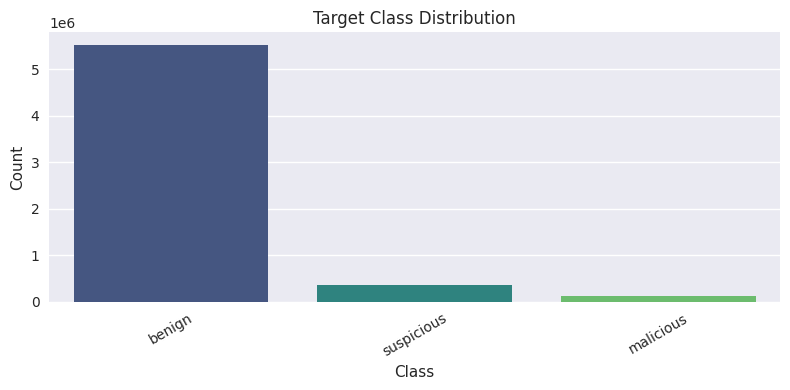

In [5]:

# Plot class distribution
plt.figure(figsize=(8, 4))
class_counts = df[TARGET_COL].astype(str).value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Target Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [6]:

# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) >= 2:
    plt.figure(figsize=(10, 7))
    corr = df[numeric_cols].corr(numeric_only=True)
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Numeric Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')


Not enough numeric columns for a correlation heatmap.



## 6. Data Cleaning (Before -> After)

We handle duplicates, missing values, and simple invalid records. Evidence is shown before and after cleaning.


In [7]:

# BEFORE
before_rows = len(df)
before_dups = df.duplicated().sum()
before_missing = df.isna().sum().sum()

print('Before cleaning:')
print('Rows:', before_rows)
print('Duplicates:', before_dups)
print('Total missing cells:', before_missing)


Before cleaning:
Rows: 6000000
Duplicates: 0
Total missing cells: 0


In [8]:

# Remove duplicate rows
clean_df = df.drop_duplicates().copy()

# Example anomaly handling:
# drop rows where target is missing
clean_df = clean_df[clean_df[TARGET_COL].notna()].copy()

# AFTER
after_rows = len(clean_df)
after_dups = clean_df.duplicated().sum()
after_missing = clean_df.isna().sum().sum()

print('After cleaning:')
print('Rows:', after_rows)
print('Duplicates:', after_dups)
print('Total missing cells:', after_missing)


After cleaning:
Rows: 6000000
Duplicates: 0
Total missing cells: 0



## 7. Feature Engineering

Domain-motivated examples:
- **`has_high_severity`**: binary indicator if severity score/category is high.
- **`event_hour`**: hour extracted from timestamp to capture temporal attack patterns.
- **`is_weekend_event`**: may capture abnormal off-hours activity.

Features are created only from existing columns. If a column is missing in this dataset, the step is skipped safely.


In [9]:

fe_df = clean_df.copy()

# 1) high severity flag
severity_candidates = [c for c in fe_df.columns if 'severity' in c.lower()]
if severity_candidates:
    sev_col = severity_candidates[0]
    if pd.api.types.is_numeric_dtype(fe_df[sev_col]):
        threshold = fe_df[sev_col].median()
        fe_df['has_high_severity'] = (fe_df[sev_col] >= threshold).astype(int)
    else:
        fe_df['has_high_severity'] = fe_df[sev_col].astype(str).str.lower().isin(['high', 'critical']).astype(int)

# 2) timestamp-based features
time_candidates = [c for c in fe_df.columns if ('time' in c.lower() or 'date' in c.lower())]
if time_candidates:
    tcol = time_candidates[0]
    parsed = pd.to_datetime(fe_df[tcol], errors='coerce')
    fe_df['event_hour'] = parsed.dt.hour
    fe_df['is_weekend_event'] = parsed.dt.dayofweek.isin([5, 6]).astype('float')

print('New columns created:', [c for c in ['has_high_severity', 'event_hour', 'is_weekend_event'] if c in fe_df.columns])
print('Shape after feature engineering:', fe_df.shape)


New columns created: ['event_hour', 'is_weekend_event']
Shape after feature engineering: (6000000, 12)



## 8. Data Preprocessing (Leakage-Free)

Mandatory requirement: train/test split is done **before fitting preprocessing**.
All imputers/encoders/scalers are fit only on training data using a `Pipeline` + `ColumnTransformer`.


In [10]:

X_full = fe_df.drop(columns=[TARGET_COL])
y = fe_df[TARGET_COL].astype(str)

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Detect leakage-like columns using only the training split:
# if almost every category value maps to a single target class,
# the feature likely contains direct label information.
leakage_cols = []
for col in X_train_full.select_dtypes(exclude=[np.number]).columns:
    unique_targets_per_value = y_train.groupby(X_train_full[col]).nunique()
    single_class_ratio = (unique_targets_per_value == 1).mean()
    if single_class_ratio >= 0.99:
        leakage_cols.append(col)

X_train = X_train_full.drop(columns=leakage_cols)
X_test = X_test_full.drop(columns=leakage_cols)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print('Detected leakage columns:', leakage_cols)
print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))


Detected leakage columns: ['request_path']
Train shape: (4800000, 10)
Test shape: (1200000, 10)
Numeric features: 3
Categorical features: 7



## 9. Training Baseline Models

Required baselines for classification:
1. Logistic Regression
2. Decision Tree Classifier


In [11]:

log_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

decision_tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=10, class_weight='balanced'))
])

log_reg_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)

print('Both baseline models are trained successfully.')


Both baseline models are trained successfully.


## 10. Evaluation

In [12]:

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    avg = 'binary' if y_test.nunique() == 2 else 'weighted'

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average=avg, zero_division=0),
        'Recall': recall_score(y_test, y_pred, average=avg, zero_division=0),
        'F1': f1_score(y_test, y_pred, average=avg, zero_division=0)
    }
    return metrics, y_pred

log_metrics, log_pred = evaluate_model('Logistic Regression', log_reg_model, X_test, y_test)
tree_metrics, tree_pred = evaluate_model('Decision Tree', decision_tree_model, X_test, y_test)

results = pd.DataFrame([log_metrics, tree_metrics]).sort_values('F1', ascending=False)
results


,Model,Accuracy,Precision,Recall,F1
1,Decision Tree,0.771685,0.880950,0.771685,0.816887
0,Logistic Regression,0.634244,0.925742,0.634244,0.734993


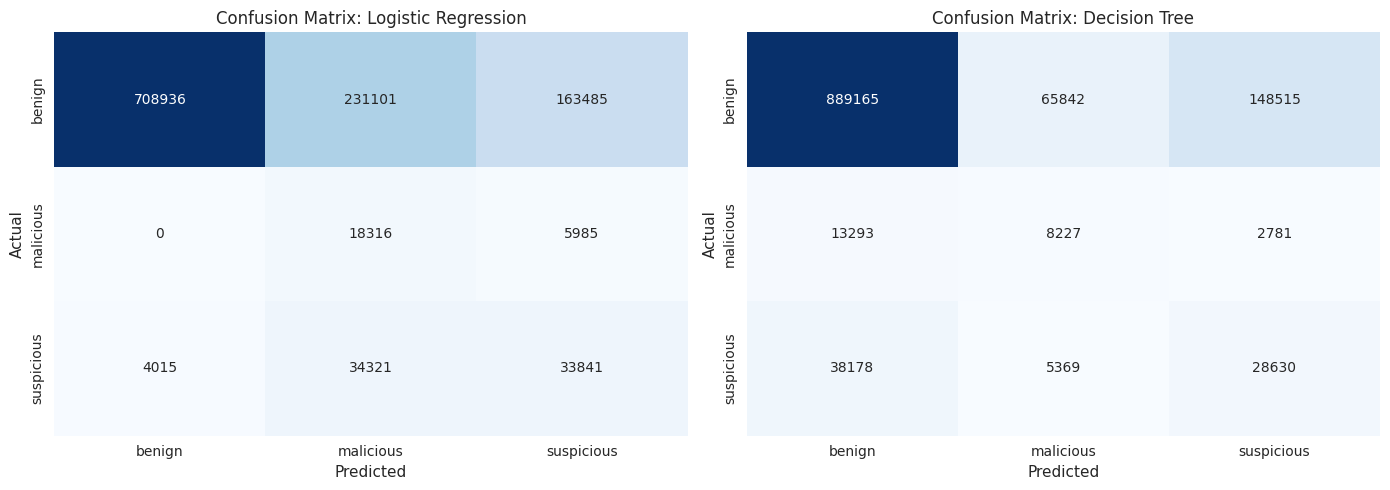

In [13]:

# Confusion matrices
models_preds = [
    ('Logistic Regression', log_pred),
    ('Decision Tree', tree_pred)
]

labels = sorted(y_test.astype(str).unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (title, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f'Confusion Matrix: {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [14]:

print('Classification report: Logistic Regression')
print(classification_report(y_test, log_pred, zero_division=0))

print('Classification report: Decision Tree')
print(classification_report(y_test, tree_pred, zero_division=0))


Classification report: Logistic Regression
              precision    recall  f1-score   support

      benign       0.99      0.64      0.78   1103522
   malicious       0.06      0.75      0.12     24301
  suspicious       0.17      0.47      0.25     72177

    accuracy                           0.63   1200000
   macro avg       0.41      0.62      0.38   1200000
weighted avg       0.93      0.63      0.73   1200000

Classification report: Decision Tree
              precision    recall  f1-score   support

      benign       0.95      0.81      0.87   1103522
   malicious       0.10      0.34      0.16     24301
  suspicious       0.16      0.40      0.23     72177

    accuracy                           0.77   1200000
   macro avg       0.40      0.51      0.42   1200000
weighted avg       0.88      0.77      0.82   1200000




## 11. Interpretation Against Business Criteria

- Compare F1 and Recall from the table with target thresholds.
- If the best model reaches acceptance targets, it can be considered a useful baseline for SOC triage support.
- If not, explain which metric failed and why this is a risk in cybersecurity practice.



## 12. Conclusion

### Key findings
- The pipeline covered end-to-end ML workflow: business framing, EDA, cleaning, feature engineering, leakage-free preprocessing, baseline training, and evaluation.
- The model comparison identified the stronger baseline for this dataset.

### Limitations
- Dataset quality and label quality may limit model performance.
- Baselines are simple and may not capture complex attack behavior.

### Next steps
- Add richer domain features (session behavior, aggregation over time windows).
- Evaluate additional models (Random Forest, XGBoost, calibrated models).
- Use cross-validation and threshold tuning for operational deployment.
